## Plot the corner plot

In [2]:
from desilike.samples import Chain
from getdist import plots

In [8]:
tracer = 'LRG1'

path = '/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_LRG1-mean25-S2-6df10e37'
chain_fns = [f'{path}/chain_0.npy']

# path1 = '/pscratch/sd/s/shengyu/Y3/redshift_errors/fits/cosmo-base_ns-fixed_QSO1-mean25-S2-b23d5c03'
# path2 = '/pscratch/sd/s/shengyu/Y3/redshift_errors/fits/cosmo-base_ns-fixed_QSO1-mean25-S2-cc756e6d'
# path3 = '/pscratch/sd/s/shengyu/Y3/data_splits/test/blinded_data/cosmo-base_ns-fixed_QSO1-S2+QSO1-S3-097023e3'
# chain_fns = [f'{path1}/chain_0.npy', f'{path2}/chain_0.npy']

params = ['h', 'omega_cdm', 'logA', f'{tracer}.b1p', f'{tracer}.b2p', f'{tracer}.bsp']

In [11]:
chains=[]

analysis_settings = {
    'smooth_scale_1D': 0.6,
    'smooth_scale_2D': 0.6,
    'fine_bins': 1024,
    'fine_bins_2D': 512,
}

for chain_fn in chain_fns:
    chain = Chain.load(chain_fn).remove_burnin(0.5)
    # chain = chain.to_getdist(params=params, settings=analysis_settings)
    # chains.append(chain)

In [12]:
chain

Chain(shape=(200, 128), params=ParameterCollection(['h', 'omega_cdm', 'omega_b', 'logA', 'n_s', 'LRG1.b1p', 'LRG1.b2p', 'LRG1.bsp', 'LRG1.X_FoG_pp', 'logposterior', 'tau_reio', 'm_ncdm', 'N_eff', 'w0_fld', 'wa_fld', 'Omega_k', 'LRG1.b3p', 'LRG1.ctp', 'H0', 'Omega_m', 'sigma8_m', 'loglikelihood', 'logprior', 'LRG1.alpha0p', 'LRG1.alpha2p', 'LRG1.alpha4p', 'LRG1.sn0p', 'LRG1.sn2p']))

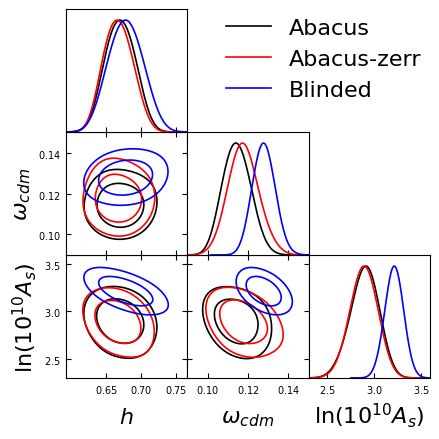

In [ ]:
g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(params) * 1.5
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    params,
    legend_loc='upper right',
    legend_labels=['Abacus','Abacus-zerr','Blinded-pocomc'],
    contour_lws=1.2,
)